# Cross-Subject Transfer Learning for ShallowFBCSPNet

## Approach

ShallowFBCSPNet has only 3 layers with ~52K parameters.
The recommended strategy is **full fine-tuning** 

## 1. Import Libraries

In [1]:
import numpy as np
import scipy.io
import scipy.linalg
import matplotlib.pyplot as plt
import os
import copy
import warnings
warnings.filterwarnings('ignore')

import braindecode
from braindecode.models import ShallowFBCSPNet
from braindecode.util import set_random_seeds

import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Braindecode version: {braindecode.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Braindecode version: 1.2.0
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Define Helper Functions

In [2]:
def load_bci_mat_file(filepath):
    mat_data = scipy.io.loadmat(filepath)
    data_struct = mat_data['data'][0]
    
    all_X, all_y, all_trials, session_info = [], [], [], []
    
    for session_idx, session in enumerate(data_struct):
        session_data = session[0][0]
        X = session_data['X']  
        fs = session_data['fs'].item() if session_data['fs'].ndim == 0 else session_data['fs'][0, 0]
        classes = session_data['classes']
        trial_field = session_data['trial']
        y_field = session_data['y']
        
        if trial_field.size > 0:
            all_X.append(X)
            all_y.append(y_field.flatten())
            all_trials.append(trial_field.flatten())
            session_info.append({
                'session_idx': session_idx,
                'fs': fs,
                'classes': [str(c.item()) for c in classes.flatten()],
                'n_trials': len(y_field.flatten())
            })
    
    return {
        'X': all_X,
        'y': np.concatenate(all_y) if all_y else np.array([]),
        'trials': np.concatenate(all_trials) if all_trials else np.array([]),
        'session_info': session_info,
        'fs': session_info[0]['fs'] if session_info else 250,
        'classes': session_info[0]['classes'] if session_info else []
    }


def extract_trial_windows(eeg_data, window_samples=1125):
    all_windows = []
    all_labels = []
    
    trial_idx = 0
    for session_idx, X_session in enumerate(eeg_data['X']):
        n_session_trials = eeg_data['session_info'][session_idx]['n_trials']
        trial_starts = eeg_data['trials'][trial_idx:trial_idx + n_session_trials]
        labels = eeg_data['y'][trial_idx:trial_idx + n_session_trials]
        
        for i, start in enumerate(trial_starts):
            end = min(start + window_samples, X_session.shape[0])
            if end - start >= window_samples:
                # Extract window and transpose to (channels, time)
                window = X_session[start:start + window_samples, :].T
                all_windows.append(window)
                all_labels.append(labels[i] - 1)  # Convert 1-4 to 0-3
        
        trial_idx += n_session_trials
    
    return np.array(all_windows), np.array(all_labels)


print("Helper functions loaded!")

Helper functions loaded!


## 3. Euclidean Alignment Implementation

**Reference**: He & Wu (2019) - "Transfer Learning for Brain-Computer Interfaces: A Euclidean Space Data Alignment Approach"


In [3]:
def euclidean_alignment(X_trials):
    n_trials, n_channels, n_times = X_trials.shape
    
    # Compute covariance matrix for each trial
    covs = []
    for trial in X_trials:
        # Covariance: (n_channels, n_times) @ (n_times, n_channels) / (n_times - 1)
        cov = np.cov(trial)
        covs.append(cov)
    
    # Compute mean covariance matrix 
    R = np.mean(covs, axis=0)
    
    # Compute R^(-1/2) using matrix square root
    # R^(-1/2) = (R^(1/2))^(-1)
    R_sqrt = scipy.linalg.sqrtm(R)
    R_inv_sqrt = np.linalg.inv(R_sqrt)
    
    R_inv_sqrt = np.real(R_inv_sqrt)
    
    # Align all trials
    X_aligned = np.array([R_inv_sqrt @ trial for trial in X_trials])
    
    return X_aligned


def euclidean_alignment_per_subject(subjects_data):
    aligned_data = {}
    
    for subj_id, (X, y) in subjects_data.items():
        print(f"  Applying EA to subject {subj_id}...")
        X_aligned = euclidean_alignment(X)
        aligned_data[subj_id] = (X_aligned, y)
    
    return aligned_data


print("Euclidean Alignment functions loaded!")

Euclidean Alignment functions loaded!


## 4. Load All Subjects Data

In [4]:
set_random_seeds(seed=42, cuda=False)

data_dir = 'data'
window_samples = 1125  # 4.5 seconds at 250 Hz
n_chans = 25
n_outputs = 4
sfreq = 250

subjects_data = {}

print("Loading EEG data for all subjects...")
print("=" * 50)

for subj_id in range(1, 10):
    for suffix in ['E', 'T']:
        filename = f'A{subj_id:02d}{suffix}.mat'
        filepath = os.path.join(data_dir, f's{subj_id}', filename)
        if os.path.exists(filepath):
            eeg_data = load_bci_mat_file(filepath)
            if len(eeg_data['session_info']) > 0:
                X_trials, y_labels = extract_trial_windows(eeg_data, window_samples=window_samples)
                subjects_data[subj_id] = (X_trials, y_labels)
                print(f"Subject {subj_id} ({filename}): {len(X_trials)} trials, shape {X_trials.shape}")
                break

print("=" * 50)
print(f"Total subjects loaded: {len(subjects_data)}")

Loading EEG data for all subjects...
Subject 1 (A01E.mat): 288 trials, shape (288, 25, 1125)
Subject 2 (A02E.mat): 288 trials, shape (288, 25, 1125)
Subject 3 (A03E.mat): 288 trials, shape (288, 25, 1125)
Subject 4 (A04E.mat): 288 trials, shape (288, 25, 1125)
Subject 5 (A05E.mat): 288 trials, shape (288, 25, 1125)
Subject 6 (A06E.mat): 288 trials, shape (288, 25, 1125)
Subject 7 (A07E.mat): 288 trials, shape (288, 25, 1125)
Subject 8 (A08E.mat): 288 trials, shape (288, 25, 1125)
Subject 9 (A09E.mat): 288 trials, shape (288, 25, 1125)
Total subjects loaded: 9


## 5. Apply Euclidean Alignment

In [5]:
print("Applying Euclidean Alignment to each subject...")
print("=" * 50)

aligned_data = euclidean_alignment_per_subject(subjects_data)

print("=" * 50)
print("Euclidean Alignment complete!")

# Verify alignment effect
print("\nVerifying alignment effect on Subject 1:")
X_before = subjects_data[1][0]
X_after = aligned_data[1][0]

# Compute average covariance before and after
cov_before = np.mean([np.cov(trial) for trial in X_before[:10]], axis=0)
cov_after = np.mean([np.cov(trial) for trial in X_after[:10]], axis=0)

print(f"Mean covariance trace before EA: {np.trace(cov_before):.4f}")
print(f"Mean covariance trace after EA:  {np.trace(cov_after):.4f}")
print(f"(After EA, trace should be closer to n_channels={n_chans})")

Applying Euclidean Alignment to each subject...
  Applying EA to subject 1...
  Applying EA to subject 2...
  Applying EA to subject 3...
  Applying EA to subject 4...
  Applying EA to subject 5...
  Applying EA to subject 6...
  Applying EA to subject 7...
  Applying EA to subject 8...
  Applying EA to subject 9...
Euclidean Alignment complete!

Verifying alignment effect on Subject 1:
  Mean covariance trace before EA: 3831.0358
  Mean covariance trace after EA:  25.6388
  (After EA, trace should be closer to n_channels=25)


## 6. Prepare Cross-Subject Splits

In [6]:
# Source subjects: 2-9 (training)
source_subjects = list(range(2, 10))

# Target subject: 1 (testing - never seen)
target_subject = 1
X_source_list = [aligned_data[i][0] for i in source_subjects]
y_source_list = [aligned_data[i][1] for i in source_subjects]

X_source = np.concatenate(X_source_list, axis=0)
y_source = np.concatenate(y_source_list, axis=0)

X_target = aligned_data[target_subject][0]
y_target = aligned_data[target_subject][1]


X_target_ft, X_target_test, y_target_ft, y_target_test = train_test_split(
    X_target, y_target, test_size=0.7, random_state=42, stratify=y_target
)

print("Cross-Subject Data Split")
print("=" * 50)
print(f"Source subjects: {source_subjects}")
print(f"Target subject: {target_subject}")
print("-" * 50)
print(f"Source data shape: {X_source.shape}")
print(f"Source label distribution: {np.bincount(y_source + 1)}")
print("-" * 50)
print(f"Target fine-tune set: {X_target_ft.shape}")
print(f"Target test set: {X_target_test.shape}")
print(f"Target ft label distribution: {np.bincount(y_target_ft + 1)}")
print(f"Target test label distribution: {np.bincount(y_target_test + 1)}")

Cross-Subject Data Split
Source subjects: [2, 3, 4, 5, 6, 7, 8, 9]
Target subject: 1
--------------------------------------------------
Source data shape: (2304, 25, 1125)
Source label distribution: [  0 576 576 576 576]
--------------------------------------------------
Target fine-tune set: (86, 25, 1125)
Target test set: (202, 25, 1125)
Target ft label distribution: [ 0 21 22 21 22]
Target test label distribution: [ 0 51 50 51 50]


## 7. Define Training Functions

In [7]:
def train_model(model, X_train, y_train, epochs=50, lr=0.001, batch_size=32, weight_decay=0.01, verbose=True):
    # Loss and optimizer
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # Convert to tensors
    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.LongTensor(y_train)
    
    # Training loop
    history = {'loss': [], 'accuracy': []}
    
    model.train()
    for epoch in range(epochs):
        # Shuffle data
        perm = torch.randperm(len(X_tensor))
        X_shuffled = X_tensor[perm]
        y_shuffled = y_tensor[perm]
        
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        # Mini-batch training
        for i in range(0, len(X_tensor), batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        
        scheduler.step()
        avg_loss = epoch_loss / (len(X_tensor) // batch_size + 1)
        acc = correct / total
        history['loss'].append(avg_loss)
        history['accuracy'].append(acc)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {acc:.4f}")
    
    return history


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test)
        outputs = model(X_tensor)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
    acc = accuracy_score(y_test, predicted.numpy())
    return acc, predicted.numpy(), probs.numpy()


print("Training functions loaded!")

Training functions loaded!


## 8. Experiment 1: Subject-Specific Baseline

Train and test on subject 1 only (using aligned data). This establishes the upper bound.

In [8]:
print("=" * 60)
print("Experiment 1: Subject-Specific Baseline (Subject 1)")
print("=" * 60)

# Split subject 1 data into train/test
X_s1_train, X_s1_test, y_s1_train, y_s1_test = train_test_split(
    X_target, y_target, test_size=0.3, random_state=42, stratify=y_target
)

print(f"Train: {X_s1_train.shape}, Test: {X_s1_test.shape}")

# Create and train model
model_baseline = ShallowFBCSPNet(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

print("\nTraining subject-specific model...")
history_baseline = train_model(
    model_baseline, X_s1_train, y_s1_train,
    epochs=50, lr=0.0005, batch_size=32
)

# Evaluate
acc_baseline, pred_baseline, _ = evaluate_model(model_baseline, X_s1_test, y_s1_test)
print(f"\n>>> Subject-Specific Test Accuracy: {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")

Experiment 1: Subject-Specific Baseline (Subject 1)
Train: (201, 25, 1125), Test: (87, 25, 1125)

Training subject-specific model...
Epoch 10/50, Loss: 0.2171, Train Acc: 0.9552
Epoch 20/50, Loss: 0.0684, Train Acc: 1.0000
Epoch 30/50, Loss: 0.0427, Train Acc: 0.9950
Epoch 40/50, Loss: 0.0468, Train Acc: 1.0000
Epoch 50/50, Loss: 0.0306, Train Acc: 1.0000

>>> Subject-Specific Test Accuracy: 0.6437 (64.37%)


## 9. Experiment 2: Pre-train General Model on Source Subjects

In [9]:
print("=" * 60)
print("Experiment 2: Pre-train General Model on Subjects 2-9")
print("=" * 60)

# Create model
model_general = ShallowFBCSPNet(
    n_chans=n_chans,
    n_outputs=n_outputs,
    n_times=window_samples,
    sfreq=sfreq,
    final_conv_length='auto'
)

print(f"Source data: {X_source.shape[0]} trials from subjects {source_subjects}")
print("\nPre-training general model...")

pretrain_config = {
    'epochs': 80,
    'lr': 0.0005,
    'batch_size': 32,
    'weight_decay': 0.01
}

history_pretrain = train_model(
    model_general, X_source, y_source,
    **pretrain_config
)

print("\nPre-training complete!")

Experiment 2: Pre-train General Model on Subjects 2-9
Source data: 2304 trials from subjects [2, 3, 4, 5, 6, 7, 8, 9]

Pre-training general model...
Epoch 10/80, Loss: 0.2645, Train Acc: 0.9158
Epoch 20/80, Loss: 0.1016, Train Acc: 0.9722
Epoch 30/80, Loss: 0.0796, Train Acc: 0.9839
Epoch 40/80, Loss: 0.0577, Train Acc: 0.9878
Epoch 50/80, Loss: 0.0439, Train Acc: 0.9918
Epoch 60/80, Loss: 0.0415, Train Acc: 0.9913
Epoch 70/80, Loss: 0.0334, Train Acc: 0.9970
Epoch 80/80, Loss: 0.0293, Train Acc: 0.9974

Pre-training complete!


## 10. Experiment 3: Zero-Shot Evaluation

Test the pre-trained model on subject 1 without any adaptation.

In [10]:
print("=" * 60)
print("Experiment 3: Zero-Shot Cross-Subject Evaluation")
print("=" * 60)
print("Testing pre-trained model on Subject 1 (never seen during training)...")

# Evaluate on target test set (no fine-tuning)
acc_zero_shot, pred_zero_shot, _ = evaluate_model(model_general, X_target_test, y_target_test)

print(f"\n>>> Zero-Shot Test Accuracy: {acc_zero_shot:.4f} ({acc_zero_shot*100:.2f}%)")
print(f">>> Random baseline: 25.00%")
print(f">>> Improvement over random: {(acc_zero_shot - 0.25) / 0.25 * 100:.1f}%")

Experiment 3: Zero-Shot Cross-Subject Evaluation
Testing pre-trained model on Subject 1 (never seen during training)...

>>> Zero-Shot Test Accuracy: 0.7426 (74.26%)
>>> Random baseline: 25.00%
>>> Improvement over random: 197.0%


## 11. Experiment 4: Full Fine-Tuning

Fine-tune ALL layers on target subject's training data with lower learning rate.

**Why full fine-tuning for ShallowFBCSPNet?**
- ShallowFBCSPNet has only 2-3 layers with ~52K parameters
- All layers are coupled to subject-specific patterns
- Freezing early layers would lock in wrong features from source subjects
- Full fine-tuning with lower LR allows adaptation while preserving learned representations

In [11]:
print("=" * 60)
print("Experiment 4: Full Fine-Tuning")
print("=" * 60)

model_finetuned = copy.deepcopy(model_general)

print(f"Fine-tuning data: {X_target_ft.shape[0]} trials from Subject 1")
print("Fine-tuning ALL layers with lower learning rate...")

# Fine-tuning configuration (lower LR, fewer epochs)
finetune_config = {
    'epochs': 30,
    'lr': 0.00005,  # 10x lower than pre-training
    'batch_size': 16,
    'weight_decay': 0.01
}

history_finetune = train_model(
    model_finetuned, X_target_ft, y_target_ft,
    **finetune_config
)

acc_finetuned, pred_finetuned, _ = evaluate_model(model_finetuned, X_target_test, y_target_test)

print(f"\n>>> Fine-Tuned Test Accuracy: {acc_finetuned:.4f} ({acc_finetuned*100:.2f}%)")
print(f">>> Improvement over zero-shot: {(acc_finetuned - acc_zero_shot) / acc_zero_shot * 100:.1f}%")

Experiment 4: Full Fine-Tuning (All Layers)
Fine-tuning data: 86 trials from Subject 1
Fine-tuning ALL layers with lower learning rate...
Epoch 10/30, Loss: 0.3704, Train Acc: 0.8372
Epoch 20/30, Loss: 0.2238, Train Acc: 0.9070
Epoch 30/30, Loss: 0.2806, Train Acc: 0.8953

>>> Fine-Tuned Test Accuracy: 0.7970 (79.70%)
>>> Improvement over zero-shot: 7.3%


## 12. Experiment 5: Comparison with Layer Freezing

For comparison, we also test the layer freezing strategy (freeze conv_time + conv_spat, only train classifier).

In [12]:
print("=" * 60)
print("Experiment 5: Layer Freezing Strategy (For Comparison)")
print("=" * 60)

model_frozen = copy.deepcopy(model_general)

print("Model layers:")
for name, module in model_frozen.named_children():
    print(f"  {name}: {type(module).__name__}")

# Freeze conv_time, conv_spat, and bn
layers_to_freeze = ['conv_time', 'conv_spat', 'bn', 'pool']
frozen_params = 0
trainable_params = 0

for name, param in model_frozen.named_parameters():
    # Check if parameter belongs to a frozen layer
    should_freeze = any(layer_name in name for layer_name in ['conv_time', 'conv_spat', 'bn'])
    if should_freeze:
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        trainable_params += param.numel()

print(f"\nFrozen parameters: {frozen_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {frozen_params + trainable_params:,}")

print("\nFine-tuning with frozen early layers...")

finetune_frozen_config = {
    'epochs': 30,
    'lr': 0.0005,  # Higher LR since only training classifier
    'batch_size': 16,
    'weight_decay': 0.01
}

history_frozen = train_model(
    model_frozen, X_target_ft, y_target_ft,
    **finetune_frozen_config
)

acc_frozen, pred_frozen, _ = evaluate_model(model_frozen, X_target_test, y_target_test)

print(f"\n>>> Frozen Layers Test Accuracy: {acc_frozen:.4f} ({acc_frozen*100:.2f}%)")

Experiment 5: Layer Freezing Strategy (For Comparison)
Model layers:
  ensuredims: Ensure4d
  dimshuffle: Rearrange
  conv_time_spat: CombinedConv
  bnorm: BatchNorm2d
  conv_nonlin_exp: Expression
  pool: AvgPool2d
  pool_nonlin_exp: SafeLog
  drop: Dropout
  final_layer: Sequential

Frozen parameters: 41,120
Trainable parameters: 11,044
Total parameters: 52,164

Fine-tuning with frozen early layers...
Epoch 10/30, Loss: 0.4164, Train Acc: 0.8488
Epoch 20/30, Loss: 0.2899, Train Acc: 0.9302
Epoch 30/30, Loss: 0.2347, Train Acc: 0.9186

>>> Frozen Layers Test Accuracy: 0.7772 (77.72%)


## 13. Results Summary

In [19]:
print("=" * 70)
print("CROSS-SUBJECT TRANSFER LEARNING RESULTS SUMMARY")
print("=" * 70)
print(f"{'Strategy':<35} {'Accuracy':>12} {'vs Baseline':>15}")
print("-" * 70)

results = [
    ('Subject-Specific Baseline', acc_baseline),
    ('Zero-Shot (no adaptation)', acc_zero_shot),
    ('Full Fine-Tuning (all layers)', acc_finetuned),
    ('Layer Freezing (freeze early)', acc_frozen),
]

baseline_acc = acc_baseline

for name, acc in results:
    diff = (acc - baseline_acc) / baseline_acc * 100
    marker = " <-- BEST" if acc == max(r[1] for r in results) else ""
    print(f"{name:<35} {acc:>11.2%} {diff:>14.1f}%{marker}")



CROSS-SUBJECT TRANSFER LEARNING RESULTS SUMMARY
Strategy                                Accuracy     vs Baseline
----------------------------------------------------------------------
Subject-Specific Baseline                64.37%            0.0%
Zero-Shot (no adaptation)                74.26%           15.4%
Full Fine-Tuning (all layers)            79.70%           23.8% <-- BEST
Layer Freezing (freeze early)            77.72%           20.7%


## 14. Visualize Results

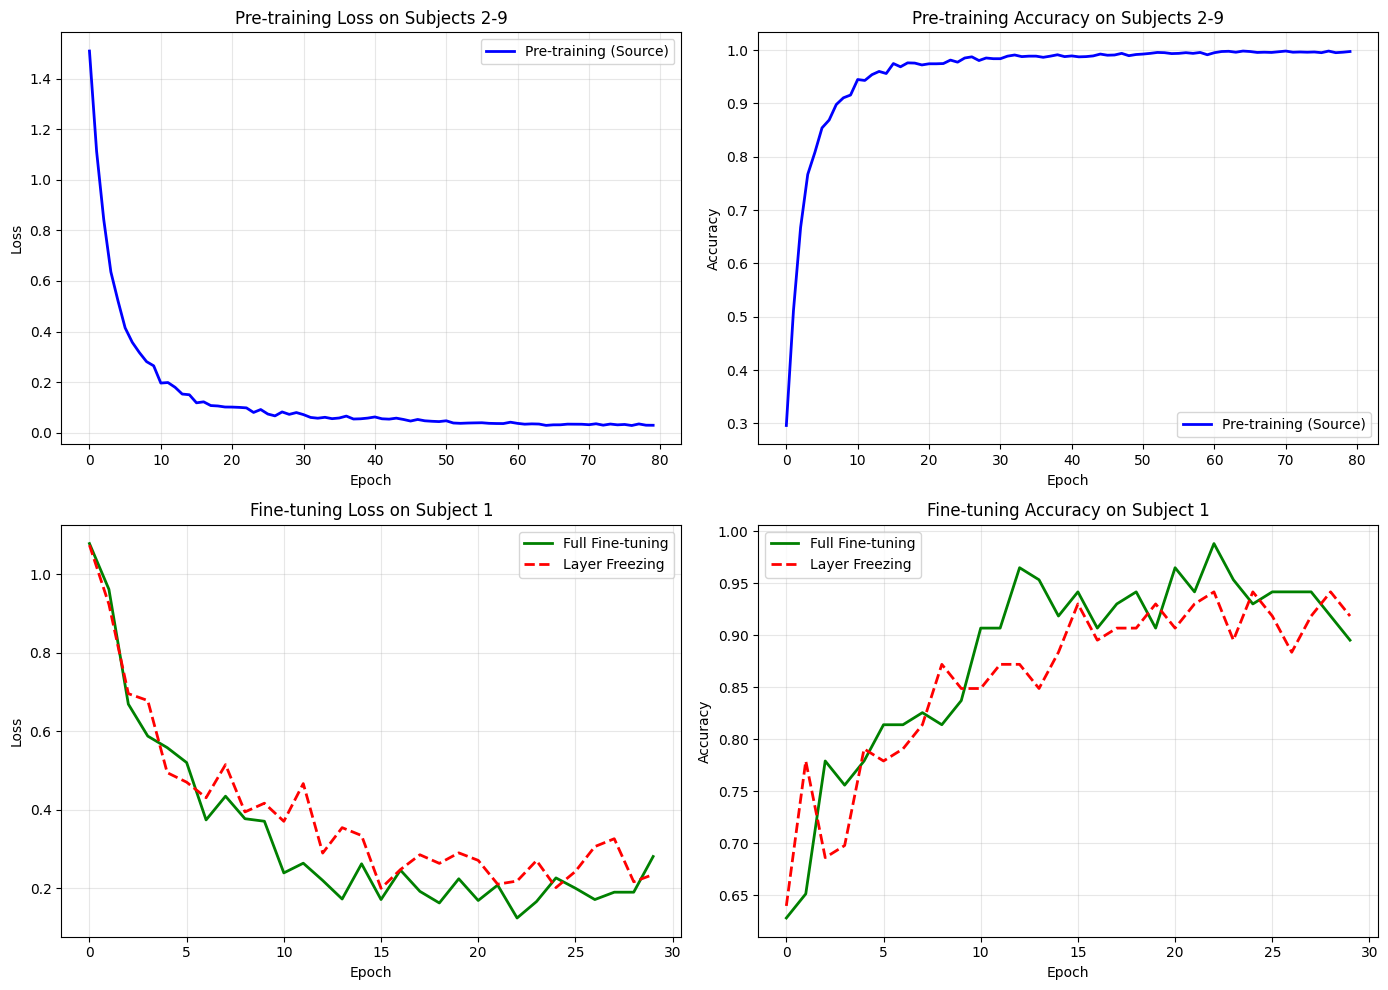


Saved: transfer_learning_curves.png


In [14]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pre-training curves
axes[0, 0].plot(history_pretrain['loss'], 'b-', linewidth=2, label='Pre-training (Source)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Pre-training Loss on Subjects 2-9')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_pretrain['accuracy'], 'b-', linewidth=2, label='Pre-training (Source)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Pre-training Accuracy on Subjects 2-9')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Fine-tuning comparison
axes[1, 0].plot(history_finetune['loss'], 'g-', linewidth=2, label='Full Fine-tuning')
axes[1, 0].plot(history_frozen['loss'], 'r--', linewidth=2, label='Layer Freezing')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Fine-tuning Loss on Subject 1')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_finetune['accuracy'], 'g-', linewidth=2, label='Full Fine-tuning')
axes[1, 1].plot(history_frozen['accuracy'], 'r--', linewidth=2, label='Layer Freezing')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Fine-tuning Accuracy on Subject 1')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transfer_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: transfer_learning_curves.png")

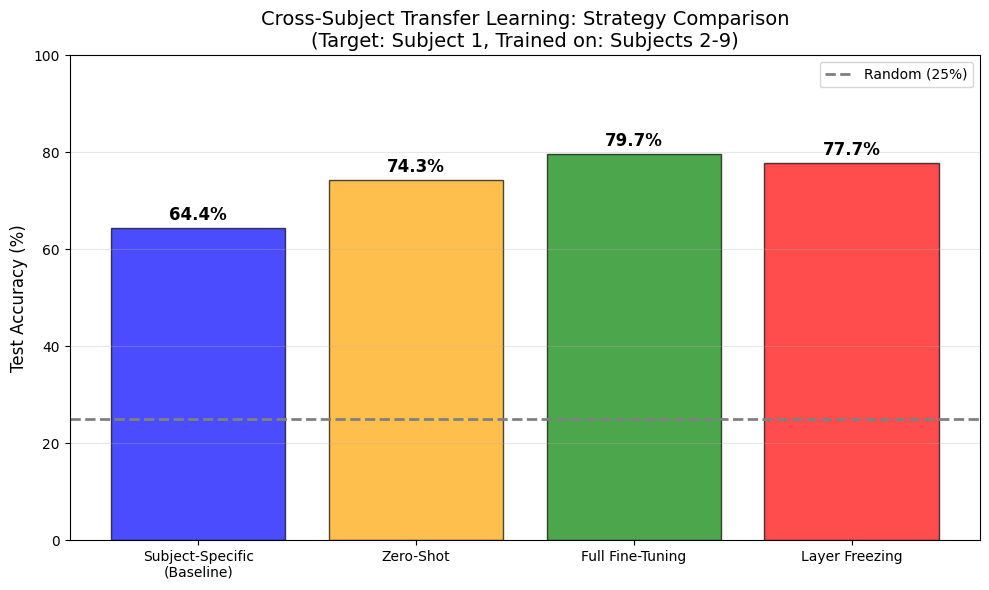


Saved: transfer_learning_comparison.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

strategies = ['Subject-Specific\n(Baseline)', 'Zero-Shot', 'Full Fine-Tuning', 'Layer Freezing']
accuracies = [acc_baseline, acc_zero_shot, acc_finetuned, acc_frozen]
colors = ['blue', 'orange', 'green', 'red']

bars = ax.bar(strategies, [a * 100 for a in accuracies], color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.annotate(f'{acc*100:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add baseline reference line
ax.axhline(y=25, color='gray', linestyle='--', linewidth=2, label='Random (25%)')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Cross-Subject Transfer Learning: Strategy Comparison\n(Target: Subject 1, Trained on: Subjects 2-9)', fontsize=14)
ax.set_ylim(0, 100)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('transfer_learning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: transfer_learning_comparison.png")

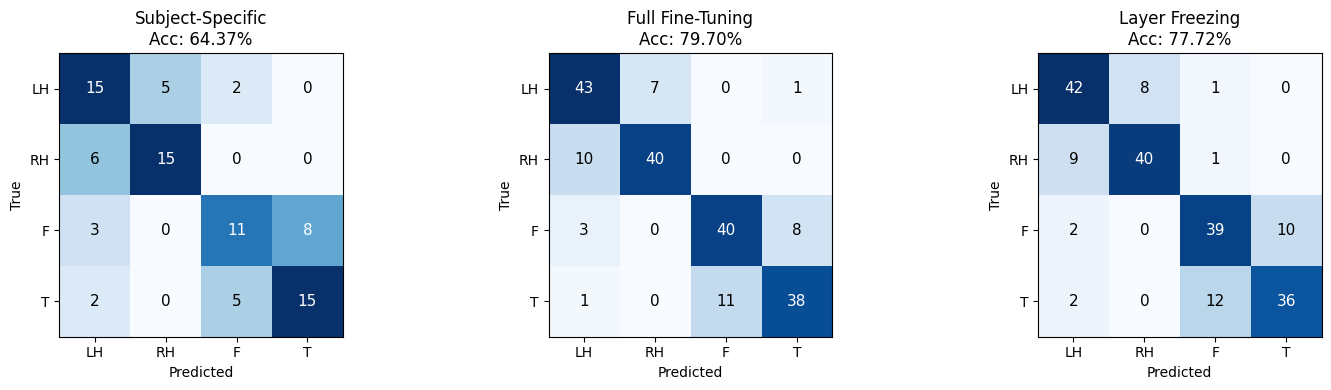


Saved: transfer_learning_confusion.png


In [16]:
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = [
    ('Subject-Specific', pred_baseline, y_s1_test),
    ('Full Fine-Tuning', pred_finetuned, y_target_test),
    ('Layer Freezing', pred_frozen, y_target_test)
]

for idx, (name, pred, true) in enumerate(predictions):
    cm = confusion_matrix(true, pred)
    acc = accuracy_score(true, pred)
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{name}\nAcc: {acc:.2%}', fontsize=12)
    axes[idx].set_xticks(range(4))
    axes[idx].set_yticks(range(4))
    axes[idx].set_xticklabels(['LH', 'RH', 'F', 'T'], fontsize=10)
    axes[idx].set_yticklabels(['LH', 'RH', 'F', 'T'], fontsize=10)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    
    for i in range(4):
        for j in range(4):
            axes[idx].text(j, i, cm[i, j], ha='center', va='center',
                          color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=11)

plt.tight_layout()
plt.savefig('transfer_learning_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: transfer_learning_confusion.png")